In [20]:
from py import PipelineWrapper
from astropy.io import fits
import numpy as np
import glob
from py.SPHERExUtility import interpolate_array, make_chunk_map, make_chunk_mask, visualize_chunk_map
import matplotlib.pyplot as plt
# Import LogNorm
from matplotlib.colors import LogNorm

In [3]:
detector = 2
exposure_list = glob.glob(f'/data1/SPHEREx/deep_north/*/*/*/*D{detector}*.fits')
for exp_file in exposure_list:
    hdul = fits.open(exp_file)
    header = hdul[1].header
    good_astrometry = header.get('FINAST', 2)
    if good_astrometry != 0:
        print(f"Skipping {exp_file} due to poor astrometry (FINAST={good_astrometry})")
        exposure_list.remove(exp_file)
print(f"Found {len(exposure_list)} exposures")

Skipping /data1/SPHEREx/deep_north/2025W17_4B/l2b-v1-2025-116/2/level2_2025W17_4B_0030_4D2_spx_l2b-v1-2025-116.fits due to poor astrometry (FINAST=1)
Skipping /data1/SPHEREx/deep_north/2025W17_4B/l2b-v1-2025-116/2/level2_2025W17_4B_0021_3D2_spx_l2b-v1-2025-116.fits due to poor astrometry (FINAST=1)
Skipping /data1/SPHEREx/deep_north/2025W20_1C/l2b-v3-2025-134/2/level2_2025W20_1C_0209_1D2_spx_l2b-v3-2025-134.fits due to poor astrometry (FINAST=2)
Found 1834 exposures


In [5]:
config = {}
config['output_dir'] = '/home/thomasli/spherex/selfcal/outputs'
config['run_name'] = f'nep_det{detector}_6p2arcsec'
config['resolution_arcsec'] = 6.2
# config['ref_path'] = '/home/thomasli/spherex/selfcal/outputs/common_ref.fits'

rr = PipelineWrapper.Reprojector(config, exposure_list=exposure_list)

NameError: name 'exposure_list' is not defined

In [5]:
rr.define_reference(padding_pixels=100, use_ext=[1])

Loading reference frame from: /home/thomasli/spherex/selfcal/outputs/nep_det2_6p2arcsec/ref.fits
Mosaic shape: (7465, 8563)
Mosaic WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 268.96647330007 65.780828426404 
CRPIX : 4475.5528907477 3807.4037035386 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0017222222222222 0.0017222222222222 
NAXIS : 8563  7465


In [7]:
rr.run_reproject(max_workers=60, method='exact', padding_percentage=0.05, oversample_factor=2, 
                      sci_ext_list=[1], 
                      dq_ext_list=[2], 
                      exp_idx_list=np.arange(0, len(exposure_list)), 
                      det_idx_list=[0]*len(exposure_list),
                      replace_existing=False)

Starting batch reprojection. Output will be saved to: /home/thomasli/spherex/selfcal/outputs/nep_det2_6p2arcsec/reprojected


Reprojecting frames: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1834/1834 [00:01<00:00, 1303.32it/s]


Batch reprojection completed. 1834 frames successfully processed out of 1834.


In [8]:
chunk_map = make_chunk_map(2, interp_factor=5)
chunk_valid_mask = make_chunk_mask([4], interp_factor=5)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87/87 [00:05<00:00, 16.25it/s]


In [6]:
cc = PipelineWrapper.Calibrator(config)

# cc.setup_lsqr(
#     apply_mask=True, 
#     apply_weight=True, 
#     chunk_map=chunk_map, 
#     chunk_valid_mask=chunk_valid_mask, 
#     max_workers=20, 
#     outlier_thresh=3.0
#     )

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1834/1834 [00:00<00:00, 1425301.75it/s]

Loading reference frame from: /home/thomasli/spherex/selfcal/outputs/nep_det2_6p2arcsec/ref.fits


In [7]:
# cc.apply_lsqr(x0=None, atol=1e-05, btol=1e-05, damp=1e-2, iter_lim=200)

In [8]:
# cal_path = cc.save_calibration(cal_file='single_test.h5')

In [9]:
mm = PipelineWrapper.Mosaicker(config)
# mm.load_calibration(cal_path=cal_path)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1834/1834 [00:00<00:00, 1429805.49it/s]

Loading reference frame from: /home/thomasli/spherex/selfcal/outputs/nep_det2_6p2arcsec/ref.fits


In [10]:
# mean, std, sc = mm.make_mosaic(
#     apply_mask=True, 
#     apply_weight=True, 
#     chunk_map=chunk_map, 
#     chunk_valid_mask=chunk_valid_mask, 
#     max_workers=40,
#     make_std_map=True, 
#     apply_sigma_clipping=True, 
#     sigma=2.0
# )

In [11]:
# mm.save_mosaic(mos_file='single_test.fits', overwrite=True)

In [ ]:
chunk_map = make_chunk_map(2, interp_factor=5)
chs = [[1], [2], [3], [5], [6], [7], [8], [9], [10], [11], [12], [13], [14], [15], [16], [17]]

for ch in chs:
    ch_name = '-'.join([str(i) for i in ch])
    print(f"Processing channels {ch_name}")
    
    chunk_valid_mask = make_chunk_mask(ch, interp_factor=5)

    cc = PipelineWrapper.Calibrator(config)

    cc.setup_lsqr(
        apply_mask=True, 
        apply_weight=True, 
        chunk_map=chunk_map, 
        chunk_valid_mask=chunk_valid_mask, 
        max_workers=20, 
        outlier_thresh=1.0
        )

    cc.apply_lsqr(x0=None, atol=1e-06, btol=1e-06, damp=1e-2, iter_lim=300)

    cal_path = cc.save_calibration(cal_file=f'cal_det2_ch{ch_name}.h5')

    mm = PipelineWrapper.Mosaicker(config)
    mm.load_calibration(cal_path=cal_path)

    mean, std, sc = mm.make_mosaic(
        apply_mask=True, 
        apply_weight=True, 
        chunk_map=chunk_map, 
        chunk_valid_mask=chunk_valid_mask, 
        max_workers=40,
        make_std_map=True, 
        apply_sigma_clipping=True, 
        sigma=2.0
    )

    mm.save_mosaic(mos_file=f'nep_6p2arcsec_det2_ch{ch_name}.fits', overwrite=True)

    clear_output(wait=True)

In [12]:
mm = PipelineWrapper.Mosaicker(config)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1834/1834 [00:00<00:00, 928019.49it/s]

Loading reference frame from: /home/thomasli/spherex/selfcal/outputs/nep_det2_6p2arcsec/ref.fits


In [13]:
mm.load_calibration(cal_path='/home/thomasli/spherex/selfcal/outputs/nep_det2_6p2arcsec/calibration/cal_det2_ch5.h5')

Calibration loaded from /home/thomasli/spherex/selfcal/outputs/nep_det2_6p2arcsec/calibration/cal_det2_ch5.h5


In [15]:
def plot_map(map, wcs):
    high, low = np.nanpercentile(map[map>0], [97, 0.001])
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection=wcs)
    im = ax.imshow(map, norm=LogNorm(vmin=low, vmax=high), origin='lower')

    # Explicitly set axis labels
    ax.coords['ra'].set_axislabel('RA')
    ax.coords['ra'].set_axislabel_position('b')  # Ensure RA label is only at the bottom
    ax.coords['ra'].set_ticks_position('b')  # Set RA ticks only at the bottom
    ax.coords['ra'].set_ticklabel_position('b')  # Set RA tick labels only at the bottom
    ax.coords['dec'].set_axislabel('DEC')

    # Add grid overlay
    ax.grid(color='black', linestyle='--', alpha=0.5)

    # Rescale the colorbar to match the height of the plot
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.040, pad=0.04)
    cbar.set_label('MJy/sr')

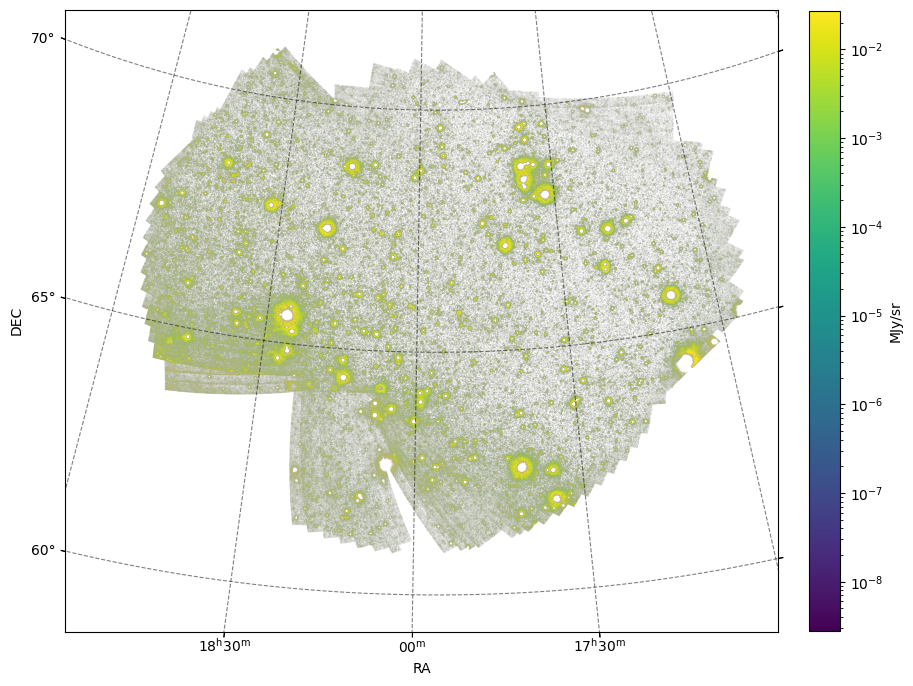

In [ ]:
plot_map(mm.S+, mm.ref_wcs)